# Transformer architecture

This is a diagram you can find all over the internet, illustrating the transformer architecture. Our job today is to understand the diagram and what all the parts do.

<img src="img/attention_research_1.png" width="500">

In [135]:
import os
import warnings
from itertools import permutations

import requests
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from sklearn.metrics import confusion_matrix, recall_score, precision_score, accuracy_score
from lark import Lark
from tqdm.notebook import tqdm

warnings.filterwarnings("ignore", message="enable_nested_tensor")

<br><br><br><br><br>

## Sample problem

We'll do it in the context of a problem to solve: identifying and then generating valid sentences in a very simple language.

Below is the entire language, expressed as a [BNF grammar](https://en.wikipedia.org/wiki/Backus%E2%80%93Naur_form):

In [2]:
parser = Lark("""
    sentence:    subj    intrans
            |    subj    trans   obj
            | pp subj    intrans
            |    subj    intrans     pp
            |    subj pp intrans
            | pp subj    trans   obj
            |    subj    trans   obj pp
            |    subj pp trans   obj

    subj:      "THE" entity |      "A" entity_cons |      "AN" entity_vowel
    obj:       "THE" entity |      "A" entity_cons |      "AN" entity_vowel
    pp:   prep "THE" place  | prep "A" place_cons  | prep "AN" place_vowel

    entity:       entity_cons | entity_vowel
    place:        place_cons | place_vowel

    entity_cons:  "CAT" | "MOUSE" | "ROBOT"
    entity_vowel: "ALLIGATOR" | "ANT"
    place_cons:   "HOUSE" | "YARD" | "STREET"
    place_vowel:  "AIRPORT" | "OCEAN"

    prep:         "IN" | "UNDER" | "ABOVE"
    intrans:      "SMILES" | "BURPS" | "SLEEPS" | "EXPLODES"
    trans:        "CHASES" | "EATS" | "LOVES" | "HATES"

    %ignore " "
""", start="sentence", parser="lalr", keep_all_tokens=True)

This parser does the task algorithmically (`LALR(1)`). We'll want to train a model to do the same task.

In [3]:
print(parser.parse("THE CAT SMILES").pretty(indent_str="    ").replace("\t", ": "))

sentence
    subj
        THE
        entity
            entity_cons: CAT
    intrans: SMILES


In [4]:
print(parser.parse("THE CAT EATS A MOUSE IN THE STREET").pretty(indent_str="    ").replace("\t", ": "))

sentence
    subj
        THE
        entity
            entity_cons: CAT
    trans: EATS
    obj
        A
        entity_cons: MOUSE
    pp
        prep: IN
        THE
        place
            place_cons: STREET


<br><br><br><br><br>

Data will be given to the model as lists of 8 tokens, using `<BLANK>` as filler at the end.

This `is_valid` function is a drop-in replacement for what we'll want our first model to do.

In [5]:
BLANK = "<BLANK>"

SEQUENCE_LENGTH = 8

def is_valid(tokens):
    # length must be SEQUENCE_LENGTH
    if len(tokens) != SEQUENCE_LENGTH:
        return False

    # all tokens after the first BLANK must be BLANK, allowing for no BLANKs by adding one
    if not all(x == BLANK for x in tokens[(tokens + [BLANK]).index(BLANK):]):
        return False

    try:
        # try to parse the string without BLANKs
        parser.parse(" ".join([x for x in tokens if x != BLANK]))
        return True
    except Exception:
        return False

In [6]:
is_valid(["THE", "CAT", "SMILES", BLANK, BLANK, BLANK, BLANK, BLANK])

True

In [7]:
is_valid(["THE", "CAT", "EATS", "A", "MOUSE", "IN", "THE", "STREET"])

True

In [8]:
is_valid(["THE", "CAT", "EATS", BLANK, BLANK, BLANK, BLANK, BLANK])

False

<br><br><br><br><br>

## Dataset for this sample problem

Random sentences labeled by validity, in which 50% are `ok` and 50% are `bad`.

In [9]:
train_df = pd.read_csv("data/train.csv",    nrows=20000)
valid_df = pd.read_csv("data/validate.csv", nrows=20000)
testy_df = pd.read_csv("data/test.csv",     nrows=20000)

In [10]:
train_df

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,ABOVE,A,STREET,THE,MOUSE,HATES,A,CAT,ok
1,IN,A,HOUSE,AN,ANT,CHASES,A,MOUSE,ok
2,IN,THE,STREET,THE,ANT,CHASES,THE,ANT,ok
3,IN,MOUSE,YARD,A,ROBOT,A,LOVES,A,bad
4,IN,A,YARD,ANT,ALLIGATOR,CHASES,AN,AN,bad
...,...,...,...,...,...,...,...,...,...
19995,A,ROBOT,CHASES,THE,ANT,UNDER,AN,AIRPORT,ok
19996,UNDER,AN,OCEAN,AN,ANT,HATES,THE,ALLIGATOR,ok
19997,AIRPORT,THE,AIRPORT,CAT,ALLIGATOR,LOVES,A,MOUSE,bad
19998,THE,ALLIGATOR,LOVES,AN,ANT,UNDER,A,YARD,ok


<br><br><br><br><br>

One-hot encoding for the 25 tokens:

In [11]:
TOKEN_INDEX = {
    x: i for i, x in enumerate([
        "THE", "A", "AN",
        "CAT", "MOUSE", "ROBOT", "ALLIGATOR", "ANT",
        "HOUSE", "YARD", "STREET", "AIRPORT", "OCEAN",
        "IN", "UNDER", "ABOVE",
        "SMILES", "BURPS", "SLEEPS", "EXPLODES",
        "CHASES", "EATS", "LOVES", "HATES",
        BLANK
    ])
}
VOCABULARY_SIZE = len(TOKEN_INDEX)

def df_to_onehot(df):
    x = torch.zeros((len(df), SEQUENCE_LENGTH, VOCABULARY_SIZE))
    token_columns = [f"t{i}" for i in range(SEQUENCE_LENGTH)]
    indexes = df[token_columns].apply(lambda col: col.map(TOKEN_INDEX).values)
    
    for i, colname in enumerate(token_columns):
        x[torch.arange(len(df)), i, indexes[colname]] = 1

    y = torch.tensor((df["label"] == "ok").astype(int).values, dtype=torch.long)

    return x, y

train_x, train_y = df_to_onehot(train_df)
valid_x, valid_y = df_to_onehot(valid_df)
testy_x, testy_y = df_to_onehot(testy_df)

<br><br><br><br><br>

Look at the first one in the training data:

In [12]:
train_df.iloc[:1]

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,ABOVE,A,STREET,THE,MOUSE,HATES,A,CAT,ok


In [13]:
print(" " + " ".join(f"{x[:4]:4s}" for x in TOKEN_INDEX))
for i in range(SEQUENCE_LENGTH):
    print(str(train_x[0, i].tolist()).replace("0.0", "   "))

 THE  A    AN   CAT  MOUS ROBO ALLI ANT  HOUS YARD STRE AIRP OCEA IN   UNDE ABOV SMIL BURP SLEE EXPL CHAS EATS LOVE HATE <BLA
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ]
[   ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    , 1.0,    ]
[   , 1.0,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,    ,   

<br><br><br><br><br>

## Prepare for training

We'll use the same procedure to train all models.

In [60]:
def train(
    model, train_x, train_y, valid_x, valid_y,
    num_epochs=50, batch_size=128, lr=1e-3, weight_decay=5e-4,
):
    "General-purpose training function; works for all models."

    loader = DataLoader(TensorDataset(train_x, train_y), batch_size=batch_size)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    best_loss, wait = np.inf, 0
    
    train_losses, valid_losses = [], []
    for epoch in tqdm(range(num_epochs)):
        model.train()  # tell PyTorch we're in "training mode"
    
        train_loss = 0
        for batch_x, batch_y in loader:
            # compute the loss for a batch of model predictions and targets
            loss = loss_fn(model(batch_x), batch_y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * len(batch_x)
        train_loss /= len(train_x)
        train_losses.append(train_loss)
    
        model.eval()  # tell PyTorch we're in "evaluation mode"
    
        with torch.no_grad():  # focus only on values, not derivatives
            valid_loss = loss_fn(model(valid_x), valid_y).item()
        valid_losses.append(valid_loss)

    return train_losses, valid_losses

<br><br><br><br><br>

## Old-fashioned neural network

For each data row, we have 8 tokens, and each token is represented by a 25-dimensional one-hot vector.

For an old-fashioned, fully-connected neural network, just flatten it to a 8×25 = 200-dimensional input vector.

In [61]:
train_flat_x = train_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)
valid_flat_x = valid_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)
testy_flat_x = testy_x.reshape(-1, SEQUENCE_LENGTH * VOCABULARY_SIZE)

In [62]:
train_x.shape

torch.Size([20000, 8, 25])

In [63]:
train_flat_x.shape

torch.Size([20000, 200])

<br><br><br><br><br>

The model has a hidden layer of length 128 and then a two-class decision space.

In [64]:
HIDDEN_LAYER = 128

model_mlp = nn.Sequential(
    nn.Linear(SEQUENCE_LENGTH * VOCABULARY_SIZE, HIDDEN_LAYER),
    nn.ReLU(),
    nn.Linear(HIDDEN_LAYER, 2),
)

train_losses, valid_losses = train(model_mlp, train_flat_x, train_y, valid_flat_x, valid_y)

  0%|          | 0/50 [00:00<?, ?it/s]

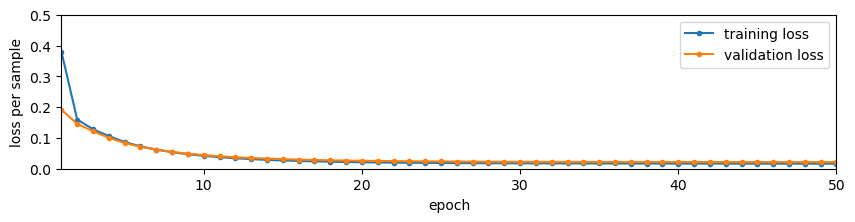

In [65]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per sample")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 0.5)
ax.legend()

None

<br><br><br><br><br>

It's a good model.

In [66]:
model_mlp.eval()
with torch.no_grad():
    testy_predictions = model_mlp(testy_flat_x).argmax(dim=1).numpy()

confusion_matrix(testy_y.numpy(), testy_predictions)

array([[ 9845,   102],
       [    0, 10053]])

In [67]:
accuracy_score(testy_y.numpy(), testy_predictions)

0.9949

In [68]:
precision_score(testy_y.numpy(), testy_predictions)

0.9899556868537667

In [69]:
recall_score(testy_y.numpy(), testy_predictions)

1.0

<br><br><br><br><br>

## Now with half a transformer

To decide if a sentence is valid, we only need half a transformer: tokens go into the encoder and then the encoder's output gets passed through a 2-class decision (whatever size the vector is → 2 dimensions).

<img src="img/encoder-only.png" width="500">

We could use our 25-dimensional one-hot vector as an embedding, but I got better results with a smaller embedding space.

`d_model` = 16 is the size of the embedding space and everything else inside the `TransformerEncoderLayer`.

In [70]:
class Encoder(nn.Module):
    def __init__(self, position_embedding: bool, d_model=16, nhead=1, num_layers=1, dim_feedforward=64):
        super().__init__()

        # the one-hot encoded inputs are an inconvenient size; expand them to d_model
        self.input_embedding = nn.Linear(VOCABULARY_SIZE, d_model, bias=False)

        # we'll test it with and without a position embedding 
        if position_embedding:
            self.position_embedding = nn.Embedding(SEQUENCE_LENGTH, d_model)
        else:
            self.position_embedding = None

        # here's a prototypical encoder layer
        layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0, batch_first=True, norm_first=True,
        )
        # now make num_layers of them
        self.encoder = nn.TransformerEncoder(layer, num_layers=num_layers)

        # the two-class decision
        self.decision = nn.Linear(d_model, 2)

    def forward(self, x):
        embedded = self.input_embedding(x)

        if self.position_embedding is not None:
            embedded += self.position_embedding(torch.arange(x.size(1), device=x.device))

        out = self.encoder(embedded)

        return self.decision(out.mean(dim=1))

<br><br><br><br><br>

## No position encoding

Train an encoder with _no_ position encoding.

In [71]:
model_encoder_none = Encoder(position_embedding=False)

train_losses, valid_losses = train(model_encoder_none, train_x, train_y, valid_x, valid_y)

  0%|          | 0/50 [00:00<?, ?it/s]

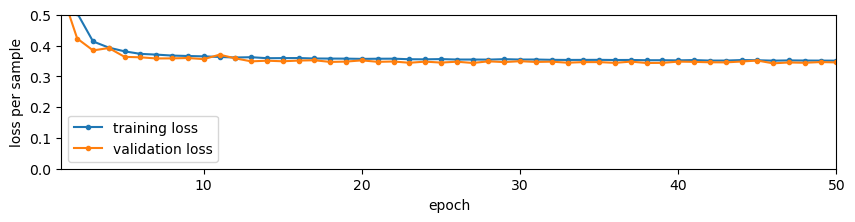

In [72]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per sample")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 0.5)
ax.legend()

None

<br><br><br><br><br>

The model quality is poor:

In [73]:
model_encoder_none.eval()
with torch.no_grad():
    testy_predictions = model_encoder_none(testy_x).argmax(dim=1).numpy()

confusion_matrix(testy_y.numpy(), testy_predictions)

array([[7083, 2864],
       [ 104, 9949]])

In [74]:
accuracy_score(testy_y.numpy(), testy_predictions)

0.8516

In [75]:
precision_score(testy_y.numpy(), testy_predictions)

0.7764770155311013

In [76]:
recall_score(testy_y.numpy(), testy_predictions)

0.9896548294041579

<br><br><br><br><br>

But that's because it's trying to validate sentences without knowing how they're ordered.

In [77]:
permuted_sentence = pd.DataFrame(
    permutations(["THE", "CAT", "EATS", "THE", "MOUSE", "IN", "THE", "YARD"]),
    columns=[f"t{i}" for i in range(8)],
)
permuted_sentence["label"] = [is_valid(list(row)) for _, row in permuted_sentence.iterrows()]
permuted_sentence

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,THE,CAT,EATS,THE,MOUSE,IN,THE,YARD,True
1,THE,CAT,EATS,THE,MOUSE,IN,YARD,THE,False
2,THE,CAT,EATS,THE,MOUSE,THE,IN,YARD,False
3,THE,CAT,EATS,THE,MOUSE,THE,YARD,IN,False
4,THE,CAT,EATS,THE,MOUSE,YARD,IN,THE,False
...,...,...,...,...,...,...,...,...,...
40315,YARD,THE,IN,MOUSE,THE,THE,EATS,CAT,False
40316,YARD,THE,IN,MOUSE,THE,CAT,THE,EATS,False
40317,YARD,THE,IN,MOUSE,THE,CAT,EATS,THE,False
40318,YARD,THE,IN,MOUSE,THE,EATS,THE,CAT,False


In [78]:
permuted_sentence_x, permuted_sentence_y = df_to_onehot(permuted_sentence)

permuted_sentence_predictions = model_encoder_none(permuted_sentence_x).detach().numpy()
permuted_sentence_predictions

array([[-0.5545958 ,  0.6006717 ],
       [-0.55459577,  0.6006716 ],
       [-0.55459577,  0.60067165],
       ...,
       [-0.5545959 ,  0.6006719 ],
       [-0.55459595,  0.60067195],
       [-0.55459595,  0.60067195]], shape=(40320, 2), dtype=float32)

The model predicts the same 2-dimensional logits for all 40320 permutations.

In [79]:
abs(permuted_sentence_predictions - list(permuted_sentence_predictions[0])).max()

np.float32(3.5762787e-07)

<br><br><br><br><br>

But it does learn how many verbs a sentence ought to have.

In [80]:
parts_of_speech = pd.DataFrame([
    ["THE", "CAT", "SMILES",   BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "BURPS",    BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "SLEEPS",   BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "EXPLODES", BLANK,      BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "SMILES",   "SMILES",   BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "BURPS",    "BURPS",    BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "SLEEPS",   "SLEEPS",   BLANK, BLANK, BLANK, BLANK],
    ["THE", "CAT", "EXPLODES", "EXPLODES", BLANK, BLANK, BLANK, BLANK],
], columns=[f"t{i}" for i in range(8)])
parts_of_speech["label"] = [is_valid(list(row)) for _, row in parts_of_speech.iterrows()]
parts_of_speech

,t0,t1,t2,t3,t4,t5,t6,t7,label
0,THE,CAT,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
1,THE,CAT,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
2,THE,CAT,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
3,THE,CAT,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True
4,THE,CAT,SMILES,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
5,THE,CAT,BURPS,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
6,THE,CAT,SLEEPS,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False
7,THE,CAT,EXPLODES,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False


In [81]:
parts_of_speech_x, parts_of_speech_y = df_to_onehot(parts_of_speech)

parts_of_speech["probability"] = model_encoder_none(parts_of_speech_x).softmax(-1)[:, 1].detach().numpy() * 100
parts_of_speech

,t0,t1,t2,t3,t4,t5,t6,t7,label,probability
0,THE,CAT,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,91.501442
1,THE,CAT,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,93.703300
2,THE,CAT,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,91.731606
3,THE,CAT,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,<BLANK>,True,92.126663
4,THE,CAT,SMILES,SMILES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,35.385254
5,THE,CAT,BURPS,BURPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,0.065354
6,THE,CAT,SLEEPS,SLEEPS,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,27.265728
7,THE,CAT,EXPLODES,EXPLODES,<BLANK>,<BLANK>,<BLANK>,<BLANK>,False,16.565266


<br><br><br><br><br>

Let's take a look at the query vectors, the key vectors, and the resulting attention for each token in a sentence.

Since it's a bag of words and order of other words doesn't help, the attention distribution is nearly flat.

In [82]:
def plot_attention(model, sentence):
    tokens = [TOKEN_INDEX[t] for t in sentence]
    
    # one-hot encode and embed
    one_hot = torch.zeros(1, SEQUENCE_LENGTH, VOCABULARY_SIZE)
    one_hot[0, torch.arange(SEQUENCE_LENGTH), tokens] = 1.0
    
    model.eval()
    with torch.no_grad():
        emb = model.input_embedding(one_hot)
    
    # extract W_Q, W_K, W_V from the stacked in_proj_weight (3*d_model, d_model)
    attn = model.encoder.layers[0].self_attn
    W = attn.in_proj_weight
    d_model = emb.shape[-1]
    W_Q, W_K, W_V = W[:d_model], W[d_model:2*d_model], W[2*d_model:]
    
    e = emb[0]
    Q = e @ W_Q.T
    K = e @ W_K.T
    V = e @ W_V.T
    
    d_k = d_model // attn.num_heads
    scores = Q @ K.T / d_k**0.5
    attn_weights = scores.softmax(dim=-1)
    
    fig, axes = plt.subplots(3, 1, figsize=(8, 12), gridspec_kw={"height_ratios": [1, 1, 3]})
    
    for ax, matrix, title in zip(
        axes,
        [Q.detach().numpy(), K.detach().numpy(), attn_weights.detach().numpy()],
        [f"Queries (8 × {d_model})", f"Keys (8 × {d_model})", "Attention weights: softmax(Q·Kᵀ / √d_k)"],
    ):
        im = ax.imshow(matrix, aspect="auto", cmap="Blues")
        ax.set_yticks(range(SEQUENCE_LENGTH))
        ax.set_yticklabels(sentence)
        if matrix.shape[1] == SEQUENCE_LENGTH:   # attention matrix
            ax.set_xticks(range(SEQUENCE_LENGTH))
            ax.set_xticklabels(sentence, rotation=45, ha="right")
            ax.set_xlabel("Key position (attended to)")
            ax.set_ylabel("Query position (attending from)")
            for i in range(SEQUENCE_LENGTH):
                for j in range(SEQUENCE_LENGTH):
                    ax.text(
                        j, i, f"{matrix[i, j]*100:.0f}",
                        ha="center", va="center", fontsize=12, color="yellow", fontweight="bold",
                        path_effects=[pe.withStroke(linewidth=2, foreground="black")],
                    )
        else:
            ax.set_xlabel("d_model dimension")
        ax.set_title(title)
        plt.colorbar(im, ax=ax)
    
    plt.tight_layout()

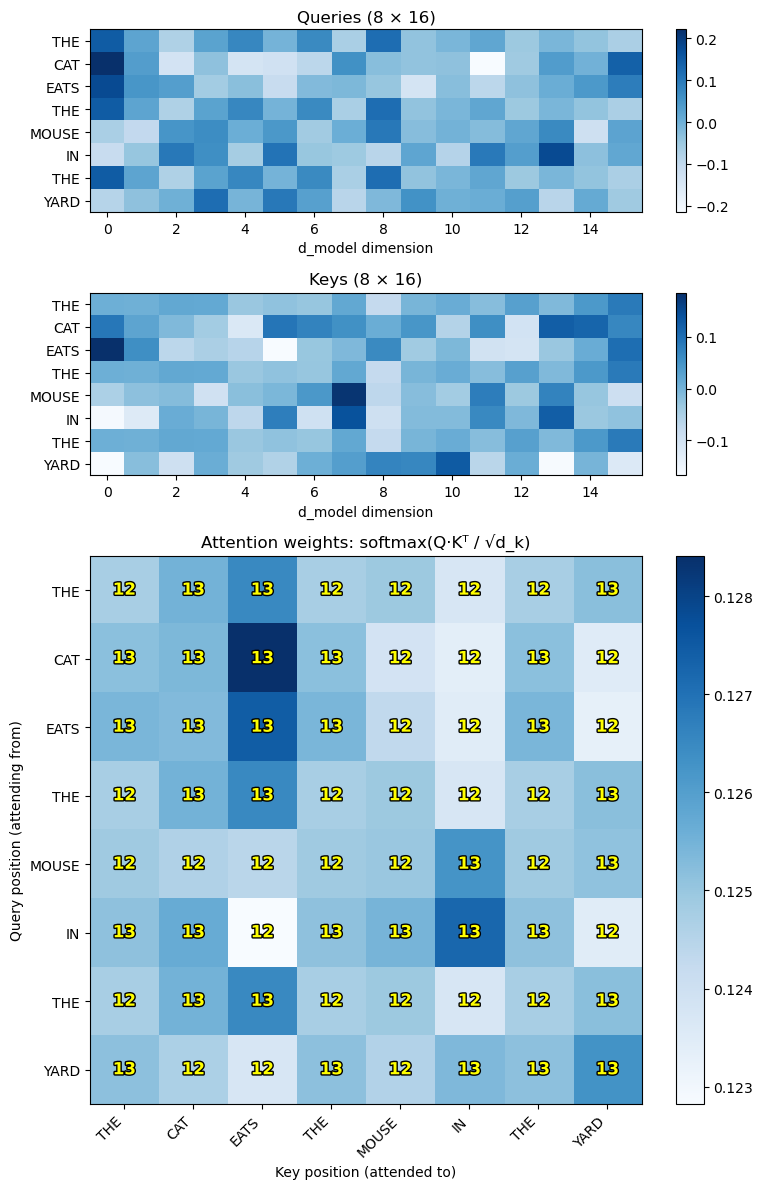

In [83]:
plot_attention(model_encoder_none, ["THE", "CAT", "EATS", "THE", "MOUSE", "IN", "THE", "YARD"])

<br><br><br><br><br>

## Learned position encoding

Now let's add a position encoding. These are just extra weights for the optimizer to learn, and it will make them different if position matters (which it does).

In [84]:
model_encoder_learned = Encoder(position_embedding=True)

train_losses, valid_losses = train(model_encoder_learned, train_x, train_y, valid_x, valid_y)

  0%|          | 0/50 [00:00<?, ?it/s]

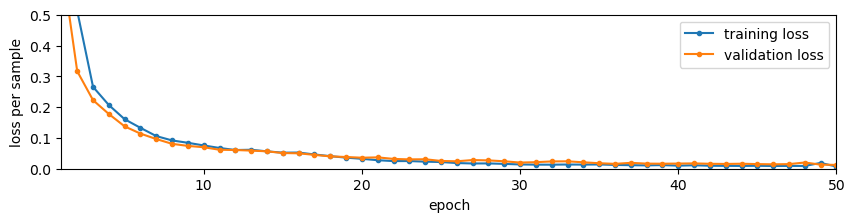

In [85]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per sample")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 0.5)
ax.legend()

None

<br><br><br><br><br>

The model quality is much better because it's sensitive to word order:

In [86]:
model_encoder_learned.eval()
with torch.no_grad():
    testy_predictions = model_encoder_learned(testy_x).argmax(dim=1).numpy()

confusion_matrix(testy_y.numpy(), testy_predictions)

array([[ 9891,    56],
       [    0, 10053]])

In [87]:
accuracy_score(testy_y.numpy(), testy_predictions)

0.9972

In [88]:
precision_score(testy_y.numpy(), testy_predictions)

0.9944603818379661

In [89]:
recall_score(testy_y.numpy(), testy_predictions)

1.0

<br><br><br><br><br>

Now the attention distribution often highlights the verb.

(The distribution seems to be different every time I run it, but there's a tendency.)

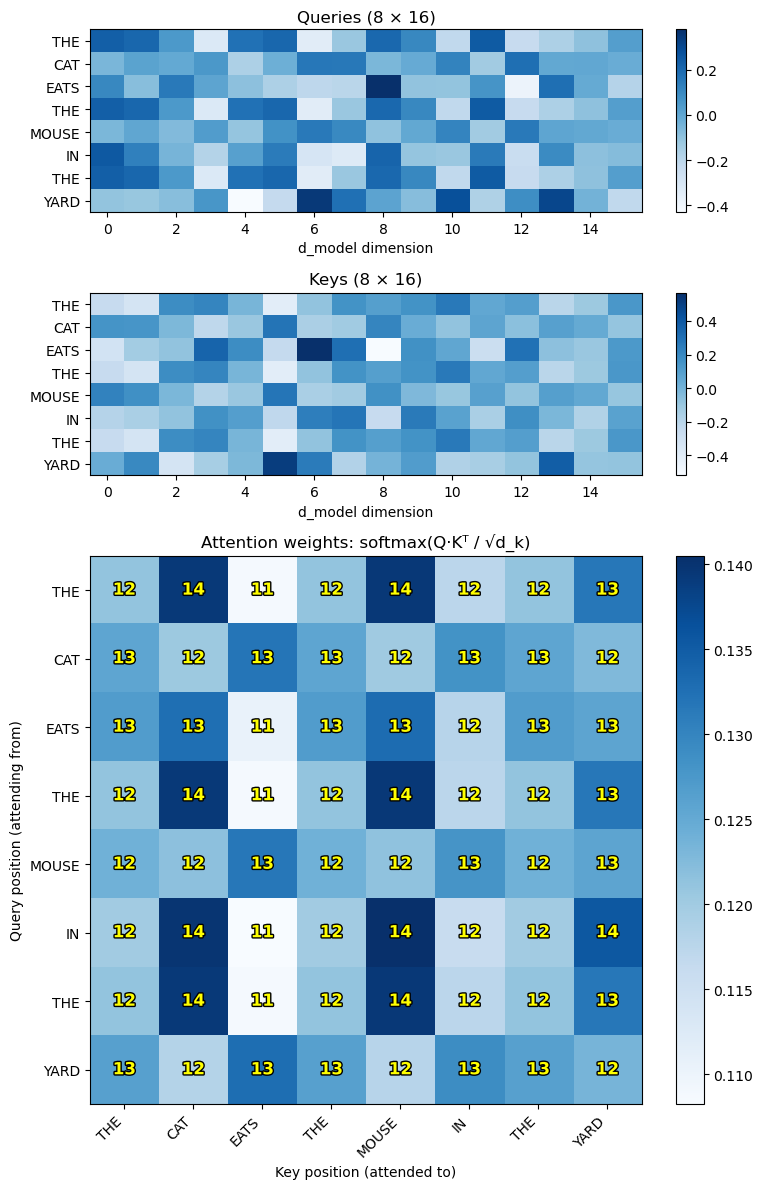

In [90]:
plot_attention(model_encoder_learned, ["THE", "CAT", "EATS", "THE", "MOUSE", "IN", "THE", "YARD"])

<br><br><br><br><br>

The query, key, and value are all computed from $e$, the embedded input (16-dimensional), by multiplying it by learned weight matrices:

$$
Q = e \cdot {W_Q}^\top \qquad K = e \cdot {W_K}^\top \qquad V = e \cdot {W_V}^\top
$$

Then the query $Q$ and keys $K$ are used to compute attention—which positions matter, given a particular input $e$—and then attention is used to weight the values $V$ and that's the result $Z$.

<img src="img/ilustrated-transformer.png" width="600">

_(From [The Ilustrated Transformer](https://jalammar.github.io/illustrated-transformer/).)_

<br><br><br><br><br>

To have two attention heads (`nhead=2`) instead of one, we could map $e$ onto 8 dimensions instead of 16: all of the weight matrices below are 8×16 instead of 16×16.

$$Q_1 = e \cdot {W_{Q_1}}^\top \qquad Q_2 = e \cdot {W_{Q_2}}^\top$$
$$K_1 = e \cdot {W_{K_1}}^\top \qquad K_2 = e \cdot {W_{K_2}}^\top$$
$$V_1 = e \cdot {W_{V_1}}^\top \qquad V_2 = e \cdot {W_{V_2}}^\top$$

So we get two attention distributions and two $Z$ matrices,

$$\text{softmax}\left(\frac{Q_1 K_1^\top}{\sqrt{d_k}}\right) V_1 = Z_1 \qquad \text{softmax}\left(\frac{Q_2 K_2^\top}{\sqrt{d_k}}\right) V_2 = Z_2$$

which we just concatenate together to get the result.

Multiple attention heads allow a model to pay attention to the inputs in different ways: maybe one ensures that a noun has an article and another ensures that the same noun is positioned correctly relative to the verb.

(Since attention heads subdivide `d_model`, more attention heads does not increase the number of parameters, but if you wanted to, you could multiply both `d_model` and `nhead` by the same factor.)

<br><br><br><br><br>

### Where are we?

Back to the diagram:

<img src="img/encoder-only.png" width="500">

The `TransformerEncoderLayer` is the grey box that can be multiplied by $N$ by setting `num_layers`.

We've talked about the orange "Multi-Head Attention" box inside it—that's the essential part.

The yellow "Add & Norm" box makes training easier:
* "Add": the input of "Multi-Head Attention" is added to its output so that it only has to learn a _correction_ to the embedding, not the whole thing. If attention has nothing to contribute, $W_V \to 0$.
* "Norm": keeps the values from wandering too far from the unit interval.
* Sometimes, "Add" is before "Norm", sometimes after. (Empirical tuning.)

The blue "Feed Forward" box makes the result nonlinear:
* Everything in "Multi-Head Attention" is linear. If you have multiple layers, linear composed with linear = linear, so you wouldn't gain anything.
* It also has an "Add & Norm" skip connection.

The "2-class decision" is just a linear map from that last nonlinear layer to the 2-dimensional logits. For probabilities of the two classes, pass it through softmax.

<br><br><br><br><br>

## RoPE position encoding

Cut for time.

<img src="img/jimmy-stewart.jpg" width="300">

Instead of adding learned vectors to each position and expecting the optimizer to make those vectors different or related as necessary, RoPE applies a fixed transformation to each embedded token: rotation by a different angle at each position.
* Adjacent positions are rotated by almost the same amount, far positions are rotated by very different amounts.
* Empirically, this is state of the art.

<br><br><br><br><br>

## Number of parameters

The old-fashioned, fully connected neural network had slightly better results than the transformer encoder.

Why bother? What's the advantage of the transformer?

<br><br><br><br><br>

Number of parameters in the fully connected neural network:

In [93]:
num_params_mlp = sum(len(x.flatten()) for x in model_mlp.parameters())
num_params_mlp

25986

Number of parameters in the encoder:

In [94]:
num_params_encoder = sum(len(x.flatten()) for x in model_encoder_learned.parameters())
num_params_encoder

3842

In [97]:
print(f"Transformer-encoder has {num_params_mlp / num_params_encoder:.1f}× fewer parameters!")

Transformer-encoder has 6.8× fewer parameters!

<br><br><br><br><br>

### MLP

The input is a concatenated one-hot vector of dimension $LV$.  The first layer maps $LV \to H$:

$$N_\text{MLP} = \underbrace{LVH}_{\text{layer 1}} + \underbrace{2H}_{\text{layer 2}} = H(LV + 2)$$

The dominant cost is **layer 1**, which must learn a separate weight for every (position, token) pair.
Adding one token position costs exactly $VH$ new parameters.

$$N_\text{MLP} = \Theta(L)$$

with constant $VH$.  If representational capacity demands $H \propto L$ (more positions → more patterns to memorize), the cost becomes $\Theta(L^2)$.

### Encoder

The attention and feed-forward blocks apply the **same weight matrices** to every token position.  For one transformer layer with feed-forward width $d_{ff}$:

$$N_\text{layer} = \underbrace{4d^2 + 4d}_{\text{self-attention}} + \underbrace{2d\,d_{ff} + d_{ff} + d}_{\text{FFN}} + \underbrace{4d}_{\text{layer norms}}$$

None of these depend on $L$.  The only $L$-dependent term is the positional encoding:

| Encoding | $L$-dependent params | 
|---|---|
| Learned PE | $Ld$ |
| RoPE | $0$ (rotation computed on-the-fly) |

So the full parameter count is:

$$N_\text{enc} = \underbrace{Vd}_{\text{token emb.}} + \underbrace{Ld}_{\text{pos. emb. (learned)}} + \underbrace{n_\text{layers}(4d^2 + 2d\,d_{ff} + \cdots)}_{\text{position-independent}} + \underbrace{2d}_{\text{head}}$$

$$N_\text{enc} = \Theta(1) \quad \text{(RoPE)} \qquad N_\text{enc} = \Theta(L) \quad \text{(learned PE)}$$

Both are $O(L)$, but the learned PE constant is $d$, vs $VH$ for the MLP.

### Comparing the constants

In this notebook: $V = 25$, $H = 128$, $d = 16$.

| | params added per new position |
|---|---|
| MLP | $VH = 25 \times 128 = 3{,}200$ |
| Encoder, learned PE | $d = 16$ |
| Encoder, RoPE | $0$ |

The MLP adds **200× more parameters per position** than learned PE.

<br><br><br><br><br>

### It's always about finding the right symmetries

Just as a **CNN** has fewer parameters than a fully connected image-learning model, a **transformer** has fewer parameters than a fully connected sequence-learning model.
* **CNN:** take advantage of x and y translational symmetry to only learn the parameters of a kernel that is reused across the image.
* **Transformer:** take advantage of recursive-language symmetry to only learn where to look for related words.

Fewer parameters → you can scale 'em up real big!

<br><br><br><br><br>

## Full encoder-decoder

Back to this:

<img src="img/attention_research_1.png" width="500">

Now our task is to _generate_ valid sentences.

<br><br><br><br><br>

Two things are different from what we've seen:

**1. Masked Multi-Head Attention** uses a *causal mask* — when generating token $t$, the decoder can only attend to positions $0$ through $t-1$. It cannot peek at tokens that haven't been produced yet.

**2. Cross-attention** in the second Multi-Head Attention block: the queries come from the decoder's own output, but the **keys and values come from the encoder**. The decoder is asking "given what I've generated so far, which encoder positions are relevant?" — and the encoder answers with its learned representation of the input.

Everything else — Add & Norm, Feed Forward, Linear, Softmax — is exactly the same as before.

In [129]:
class FullTransformer(nn.Module):
    def __init__(self, d_model=16, nhead=1, num_layers=1, dim_feedforward=256):
        super().__init__()

        self.input_embedding    = nn.Linear(VOCABULARY_SIZE, d_model, bias=False)
        self.position_embedding = nn.Embedding(SEQUENCE_LENGTH, d_model)

        enc_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0, batch_first=True, norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=num_layers)

        dec_layer = nn.TransformerDecoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=dim_feedforward,
            dropout=0, batch_first=True, norm_first=True,
        )
        self.decoder = nn.TransformerDecoder(dec_layer, num_layers=num_layers)

        self.output_projection = nn.Linear(d_model, VOCABULARY_SIZE)

    def forward(self, src, tgt, tgt_mask):
        src_pos = torch.arange(src.size(1), device=src.device)
        tgt_pos = torch.arange(tgt.size(1), device=tgt.device)
        src_emb = self.input_embedding(src) + self.position_embedding(src_pos)
        tgt_emb = self.input_embedding(tgt) + self.position_embedding(tgt_pos)

        memory = self.encoder(src_emb)

        # upper-triangular -inf mask: position t can only attend to 0..t, not to t+1, t+2, ...
        out = self.decoder(tgt_emb, memory, tgt_mask=tgt_mask)
        #                           ^^^^^^
        #              keys and values come from the encoder output (cross-attention);
        #              queries come from the decoder's masked self-attention output

        return self.output_projection(out)   # (batch, seq_len, VOCABULARY_SIZE)

<br><br><br><br><br>

We train it to predict the next token at every position in a valid sentence. The encoder sees only the first token (the "prompt"), and the decoder generates the rest one step at a time.

In [130]:
import torch.nn.functional as F

INDEX_TOKEN = {v: k for k, v in TOKEN_INDEX.items()}

def train_generative(model, num_epochs=30, batch_size=128, lr=1e-3, weight_decay=0):
    "Train on valid sentences only; encoder prompt = first token, decoder = full sentence."

    # Filter to valid sentences
    sentences = train_x[train_y == 1]       # (N, 8, vocab)
    val_sents = valid_x[valid_y == 1]

    # Encoder sees only the first token: shape (N, 1, vocab)
    src     = sentences[:, :1, :]
    val_src = val_sents[:, :1, :]

    # Decoder input: [BOS=zero, tok0, tok1, ..., tok6]
    def shifted(x):
        bos = torch.zeros(x.size(0), 1, VOCABULARY_SIZE)
        return torch.cat([bos, x[:, :-1, :]], dim=1)

    tgt_input      = shifted(sentences)
    val_tgt_input  = shifted(val_sents)
    tgt_target     = sentences.argmax(dim=-1)      # (N, 8) integer token indices
    val_tgt_target = val_sents.argmax(dim=-1)

    loader    = DataLoader(TensorDataset(src, tgt_input, tgt_target), batch_size=batch_size, shuffle=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn   = nn.CrossEntropyLoss()

    # Causal mask: -inf above the diagonal → position t cannot see t+1, t+2, ...
    causal_mask = torch.triu(torch.full((SEQUENCE_LENGTH, SEQUENCE_LENGTH), -np.inf), diagonal=1)

    train_losses, valid_losses = [], []

    for epoch in tqdm(range(num_epochs)):
        model.train()
        train_loss = 0
        for src_b, tgt_in_b, tgt_out_b in loader:
            out  = model(src_b, tgt_in_b, tgt_mask=causal_mask)   # (batch, 8, vocab)
            loss = loss_fn(out.view(-1, VOCABULARY_SIZE), tgt_out_b.view(-1))
            optimizer.zero_grad(); loss.backward(); optimizer.step()
            train_loss += loss.item() * len(src_b)
        train_loss /= len(sentences)
        train_losses.append(train_loss)

        model.eval()
        with torch.no_grad():
            val_out  = model(val_src, val_tgt_input, tgt_mask=causal_mask)
            val_loss = loss_fn(val_out.view(-1, VOCABULARY_SIZE), val_tgt_target.view(-1)).item()
        valid_losses.append(val_loss)

    return train_losses, valid_losses

In [131]:
model_full = FullTransformer()

train_losses, valid_losses = train_generative(model_full)

  0%|          | 0/30 [00:00<?, ?it/s]

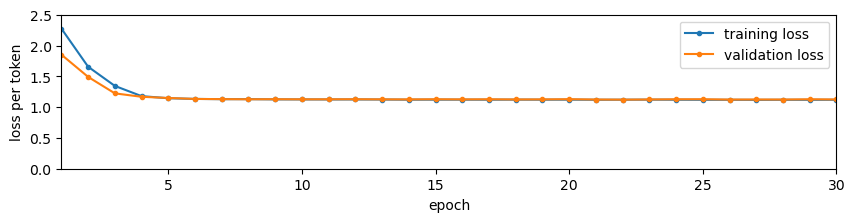

In [132]:
fig, ax = plt.subplots(figsize=(10, 2))

ax.plot(np.arange(1, len(train_losses) + 1), train_losses, marker=".", label="training loss")
ax.plot(np.arange(1, len(valid_losses) + 1), valid_losses, marker=".", label="validation loss")
ax.set_xlabel("epoch")
ax.set_ylabel("loss per token")
ax.set_xlim(1, len(train_losses))
ax.set_ylim(0, 2.5)
ax.legend()

None

<br><br><br><br><br>

In [133]:
def generate(model, start_token="THE", temperature=1.5):
    "Sample a sentence autoregressively, conditioned on start_token."
    model.eval()

    # Encoder prompt: just the starting token
    src = torch.zeros(1, 1, VOCABULARY_SIZE)
    src[0, 0, TOKEN_INDEX[start_token]] = 1.0

    # Decoder starts with [BOS, start_token]
    tgt = torch.zeros(1, 2, VOCABULARY_SIZE)
    tgt[0, 1, TOKEN_INDEX[start_token]] = 1.0

    tokens = [start_token]
    with torch.no_grad():
        for _ in range(SEQUENCE_LENGTH - 1):
            tgt_len = tgt.size(1)
            mask    = torch.triu(torch.full((tgt_len, tgt_len), float("-inf")), diagonal=1)
            out     = model(src, tgt, tgt_mask=mask)                # (1, tgt_len, vocab)
            next_idx = F.softmax(out[0, -1] / temperature, dim=0).multinomial(1).item()
            tokens.append(INDEX_TOKEN[next_idx])
            new_oh = torch.zeros(1, 1, VOCABULARY_SIZE)
            new_oh[0, 0, next_idx] = 1.0
            tgt = torch.cat([tgt, new_oh], dim=1)

    return tokens

How many of the sentences it generates, starting from "THE", are grammatically valid?

In [134]:
torch.manual_seed(1)
sentences = [generate(model_full, "THE") for _ in range(100)]

n_valid = sum(is_valid(s) for s in sentences)
print(f"{n_valid}/100 generated sentences are grammatically valid\n")

for s in sentences[:30]:
    mark = "✓" if is_valid(s) else "✗"
    print(f"  {mark}  {' '.join(s)}")

98/100 generated sentences are grammatically valid

  ✓  THE ROBOT ABOVE A HOUSE HATES A ROBOT
  ✓  THE ALLIGATOR EATS THE ALLIGATOR UNDER THE YARD
  ✓  THE ROBOT ABOVE AN AIRPORT EXPLODES <BLANK> <BLANK>
  ✓  THE ALLIGATOR CHASES A MOUSE ABOVE THE AIRPORT
  ✓  THE ALLIGATOR ABOVE A HOUSE CHASES AN ALLIGATOR
  ✓  THE ROBOT ABOVE THE AIRPORT BURPS <BLANK> <BLANK>
  ✗  THE ROBOT ABOVE THE YARD UNDER THE YARD
  ✓  THE ALLIGATOR HATES THE ANT ABOVE THE STREET
  ✓  THE CAT UNDER THE YARD EATS AN ALLIGATOR
  ✓  THE ALLIGATOR HATES AN ANT IN THE YARD
  ✓  THE ROBOT UNDER AN OCEAN SLEEPS <BLANK> <BLANK>
  ✓  THE CAT ABOVE THE YARD EATS A ROBOT
  ✓  THE ROBOT EATS THE ALLIGATOR UNDER A YARD
  ✓  THE CAT EATS A ROBOT UNDER A STREET
  ✓  THE ROBOT CHASES THE ANT UNDER THE HOUSE
  ✓  THE CAT CHASES THE ANT UNDER THE OCEAN
  ✓  THE ANT HATES THE ANT ABOVE A STREET
  ✓  THE ALLIGATOR IN A STREET SLEEPS <BLANK> <BLANK>
  ✓  THE ALLIGATOR ABOVE A HOUSE CHASES A CAT
  ✓  THE ANT EATS THE MOUSE UNDER TH

<br><br><br><br><br>

## How different is this from an LLM?

Apart from
* the number of parameters and context window
* the method of tokenization and embedding
* the size of the training dataset
* instructional reinforcement learning

what we've built above is like BERT.

The GPT family, Claude, Llama, Gemini, Mistral, etc. are even simpler: decoder-only.

<img src="img/decoder-only.png" width="500">

<br><br><br><br><br>

A very old version of ChatGPT running in completions (not chat-completions) mode:

In [ ]:
OPENAI_API_KEY = os.environ["OPENAI_API_KEY"]

In [138]:
prompt = "The cat "   # the text that will be completed

print("\n\n-----------------\n\n".join([
    prompt + choice["text"]
    for choice in requests.post(
        "https://api.openai.com/v1/completions",  # ancient, yet maintained
        headers={
            "Content-Type": "application/json",
            "Authorization": f"Bearer {OPENAI_API_KEY}"
        },
        json={
            "model": "gpt-3.5-turbo-instruct",
            "max_tokens": 100,
            "temperature": 1,  # or top_p
            "n": 5,
            "prompt": prompt,
        },
    ).json()["choices"]
]))

The cat  occupies the (x, y) position
The cat occupies the (3, 5) position.

-----------------

The cat 18 liter engine is a type of diesel engine used in heavy-duty trucks and construction equipment. It is produced by Caterpillar Inc., a leading manufacturer of construction and mining equipment, diesel and natural gas engines, industrial gas turbines, and diesel-electric locomotives. The Cat 18 liter engine is known for its durability, reliability, and high performance, making it a popular choice for industries that require powerful and efficient equipment. 

-----------------

The cat  >
Pink Floyd

The character in Pink Floyd's album "Animals" or the mysterious black cat from their song "Lucifer Sam".

-----------------

The cat 911 song."

Verse 1:
There's a feline emergency, what should I do?
My little buddy's acting strange, something's not right, it's true
He's meowing loudly, and pacing around
I don't know what's wrong, but I need to help him now

Chorus:
Cat 911, cat 911, I ne

<br><br><br><br><br>

<img src="img/llm-number-of-parameters.svg" width="1000">